# Corrective RAG (CRAG)

**The idea:** never trust retrieval blindly - GRADE the docs, and when they fail,
take corrective action (rewrite query -> web search) before generating.

This is the *minimal* corrective graph - compared to Adaptive RAG:

| | CRAG (this) | Adaptive RAG |
|---|---|---|
| Router at START | no | yes |
| Graders | docs relevance only | docs + hallucination + answer |
| Fallback shape | single terminal pass | bounded retries then fallback |

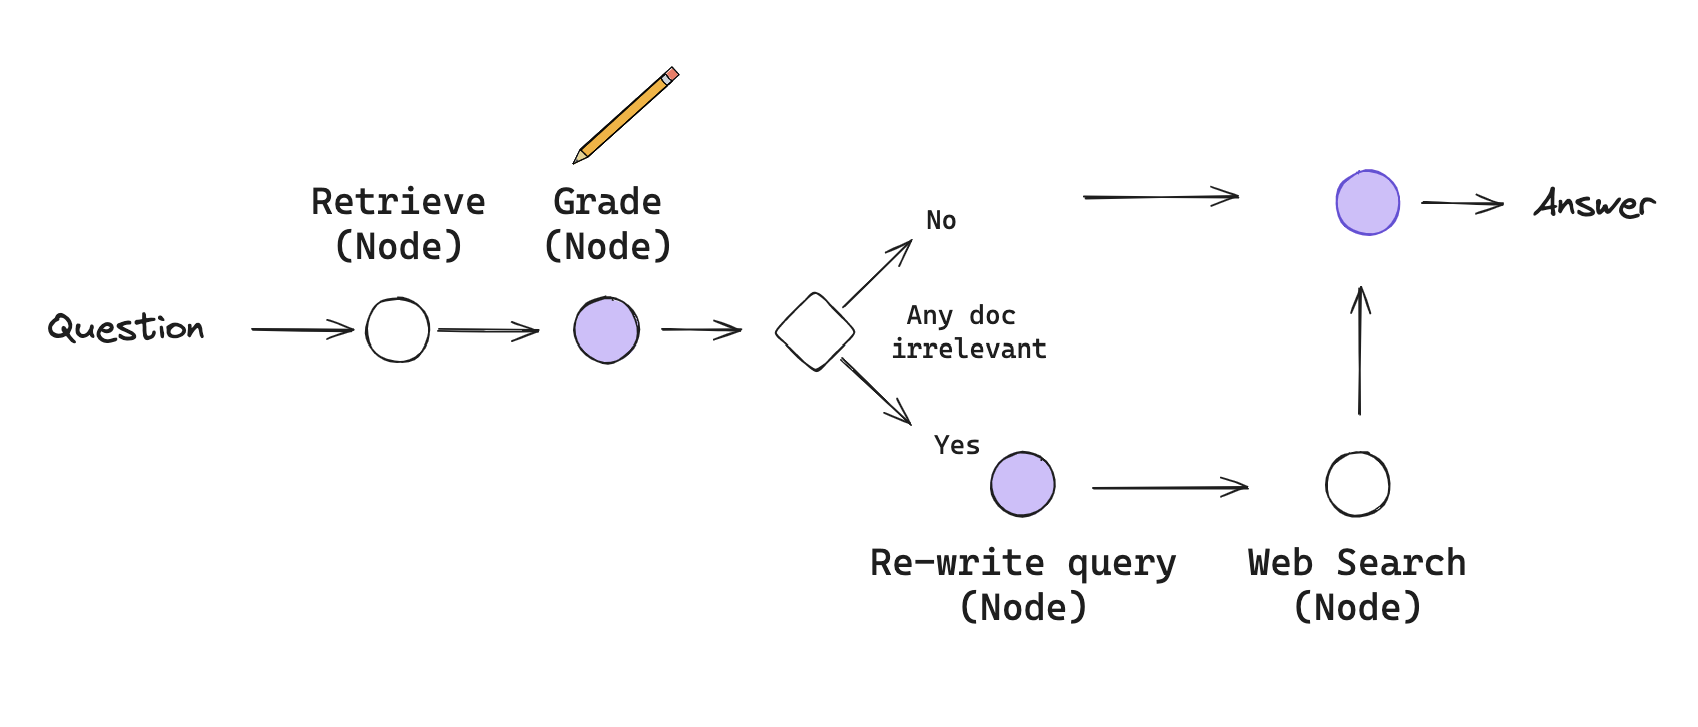

In [ ]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"]="CRAG"

Same corpus as Adaptive RAG (three Lilian Weng articles). Keeping corpora identical
across CRAG/Self-RAG/ARAG makes the graphs themselves the only variable.

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma
from langchain_ollama import OllamaEmbeddings
from langchain_core.documents import Document
import trafilatura

urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
    "https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/",
]


documents = []
for url in urls:
    downloaded = trafilatura.fetch_url(url)
    # Extracts main text and converts to markdown while stripping site chrome
    clean_text = trafilatura.extract(
        downloaded, 
        output_format="markdown", 
        include_links=False
    )
    if clean_text:
        documents.append(Document(page_content=clean_text, metadata={"source": url}))

text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=250, chunk_overlap=0
)
doc_splits = text_splitter.split_documents(documents)

# Add to vectorDB
vectorstore = Chroma.from_documents(
    documents=doc_splits,
    collection_name="rag-chroma",
    persist_directory=os.path.join(os.getcwd(), "chroma.db"),
    embedding=OllamaEmbeddings(model='nomic-embed-text'),
)
retriever = vectorstore.as_retriever()

### The ONLY grader in this notebook (ISREL)

One binary relevance judge drives the entire corrective branch.
No generation-side graders here - once we decide to generate, the answer ships unchecked.

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_ollama import ChatOllama
from pydantic import BaseModel, Field


class GradeDocs(BaseModel):
    """Binary score for releveant documents"""

    binary_score: str = Field(description="Documents are relevant to the question, 'yes' or 'no'")

llm = ChatOllama(model="gemma3:4b", temperature=0.1)
structured_llm = llm.with_structured_output(GradeDocs)

system = """You are a grader assessing relevance of a retrieved document to a user question. \n 
    If the document contains keyword(s) or semantic meaning related to the question, grade it as relevant. \n
    Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question."""

grade_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "Retrieved document: \n\n {document} \n\n User question: {question}"),
    ]
)

retrieval_grader = grade_prompt | structured_llm

question = "agent memory"
docs = retriever.invoke(question)
doc_txt = docs[1].page_content
print(retrieval_grader.invoke({"question": question, "document": doc_txt}))

Same generator chain as Adaptive RAG - unchanged on purpose.

In [ ]:
from langchain_classic import hub
from langchain_ollama import ChatOllama
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate

prompt = ChatPromptTemplate.from_template("""
# Role
You are an AI assistant focused on Question-Answering (QA) tasks within a Retrieval-Augmented Generation (RAG) system.
Your primary goal is to provide precise answers based on the given context or chat history.

# Instruction
Provide a concise, logical answer by organizing the selected content into coherent paragraphs with a natural flow. 
Avoid merely listing information. Include key numerical values, technical terms, jargon, and names. 
DO NOT use any outside knowledge or information that is not in the given material.

# Constraint
- Review the provided context thoroughly and extract key details related to the question.
- Craft a precise answer based on the relevant information.
- Keep the answer concise but logical/natural/in-depth.
- If the retrieved context does not contain relevant information or no context is available, respond with: 'I can't find the answer to that question in the context.'

**Source** (Optional)
- Cite the source of the information as a file name with a page number or URL, omitting the source if it cannot be identified.
- (list more if there are multiple sources)

# Question
<question>
{question}
</question>

# Context
<retrieved context>
{context}
</retrieved context>

# Answer
""" 
)

llm = ChatOllama(model="gemma3:4b")

def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

rag_chain = prompt | llm | StrOutputParser()

generation = rag_chain.invoke({"context": docs, "question": question})
generation

Note the prompt target: rewritten "optimized **for web search**" - the rewrite exists
to serve the fallback source, not local retrieval.

In [ ]:
llm = ChatOllama(model="gemma3:4b", temperature=0.1)

# Prompt
system = """You a question re-writer that converts an input question to a better version that is optimized \n 
     for web search. Look at the input and try to reason about the underlying semantic intent / meaning. Respond only with the question"""
re_write_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        (
            "human",
            "Here is the initial question: \n\n {question} \n Formulate an improved question.",
        ),
    ]
)

question_rewriter = re_write_prompt | llm | StrOutputParser()
question_rewriter.invoke({"question": question})

Fallback source: Tavily. In CRAG the web result is APPENDED to surviving local docs
(supplement strategy), unlike direct-routing in Adaptive RAG (replace strategy).

In [ ]:
import os
from langchain_core.tools import tool
from tavily import TavilyClient

tavily_client = TavilyClient(api_key=os.environ["TAVILY_API_KEY"])

@tool
def internet_search(
    query: str,
    max_results: int = 3,
) -> dict:
    """Search the internet for relevant sources."""
    return tavily_client.search(
        query,
        max_results=max_results,
    )

`web_search` is a control flag set by grading, read by the edge function - control data
in state, same contract rules as always.

In [ ]:
from typing import List, TypedDict

class GraphState(TypedDict):
    """
    Represents the state of our graph.

    Attributes:
        question: question
        generation: LLM generation
        web_search: whether to add search
        documents: list of documents
    """

    question: str
    generation: str
    web_search: str
    documents: List[str]

In [ ]:
from langchain_core.documents import Document

def retrieve(state):
    """
    Retrieve documents

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, documents, that contains retrieved documents
    """
    print("---RETRIEVE---")
    question = state["question"]

    # Retrieval
    documents = retriever.invoke(question)
    return {"documents": documents, "question": question}

In [ ]:
def generate(state):
    """
    Generate answer

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, generation, that contains LLM generation
    """
    print("---GENERATE---")
    question = state["question"]
    documents = state["documents"]

    # RAG generation
    generation = rag_chain.invoke({"context": documents, "question": question})
    return {"documents": documents, "question": question, "generation": generation}

In [ ]:
def grade_documents(state):
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with only filtered relevant documents
    """

    print("---CHECK DOCUMENT RELEVANCE TO QUESTION---")
    question = state["question"]
    documents = state["documents"]

    # Score each doc
    filtered_docs = []
    web_search = "No"
    for d in documents:
        score = retrieval_grader.invoke(
            {"question": question, "document": d.page_content}
        )
        grade = score.binary_score
        if grade == "yes":
            print("---GRADE: DOCUMENT RELEVANT---")
            filtered_docs.append(d)
        else:
            print("---GRADE: DOCUMENT NOT RELEVANT---")
            web_search = "Yes"
            continue
    return {"documents": filtered_docs, "question": question, "web_search": web_search}


In [ ]:
def transform_query(state):
    """
    Transform the query to produce a better question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates question key with a re-phrased question
    """

    print("---TRANSFORM QUERY---")
    question = state["question"]
    documents = state["documents"]

    # Re-write question
    better_question = question_rewriter.invoke({"question": question})
    return {"documents": documents, "question": better_question}

Supplement strategy live: appends web results to whatever survived grading
(possibly nothing). Compare with the replace-style web_search node in ARAG.

In [ ]:
def web_search(state):
    """
    Web search based on the re-phrased question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with appended web results
    """

    print("---WEB SEARCH---")
    question = state["question"]
    documents = state["documents"]

    # Web search
    docs = internet_search.invoke({"query": question})
    results = docs.get("results", [])

    web_results_text = "\n".join([d["content"] for d in results if d.get("content")])
    web_result_doc = Document(page_content=web_results_text)
    documents.append(web_result_doc)

    return {"documents": documents, "question": question}

# web_search({"documents": documents, "question": question})

Any failed doc -> rewrite + web search. Here that is acceptable because the fallback
is TERMINAL (single pass, no retry loop) - the same logic that deadlocked Adaptive RAG
is safe in this shape. Shape determines safety.

In [ ]:
def decide_to_generate(state):
    """
    Determines whether to generate an answer, or re-generate a question.

    Args:
        state (dict): The current graph state

    Returns:
        str: Binary decision for next node to call
    """

    print("---ASSESS GRADED DOCUMENTS---")
    state["question"]
    web_search = state["web_search"]
    state["documents"]

    if web_search == "Yes":
        # All documents have been filtered check_relevance
        # We will re-generate a new query
        print(
            "---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY---"
        )
        return "transform_query"
    else:
        # We have relevant documents, so generate answer
        print("---DECISION: GENERATE---")
        return "generate"

### The whole flow

```mermaid
flowchart TD
    S([START]) --> RET[retrieve]
    RET --> GD[grade_docs]
    GD -->|docs ok| GEN[generate]
    GD -->|any bad| TQ[transform_query]
    TQ --> WS[web_search]
    WS --> GEN
    GEN --> E([END])
```

The simplest of the three graphs: linear, single pass, zero cycles - cannot loop by construction.

In [ ]:
from langgraph.graph import END, StateGraph, START

workflow = StateGraph(GraphState)

# Define the nodes
workflow.add_node("retrieve", retrieve)  # retrieve
workflow.add_node("grade_documents", grade_documents)  # grade documents
workflow.add_node("generate", generate)  # generate
workflow.add_node("transform_query", transform_query)  # transform_query
workflow.add_node("web_search_node", web_search)  # web search

# Build graph
workflow.add_edge(START, "retrieve")
workflow.add_edge("retrieve", "grade_documents")
workflow.add_conditional_edges(
    "grade_documents",
    decide_to_generate,
    {
        "transform_query": "transform_query",
        "generate": "generate",
    },
)
workflow.add_edge("transform_query", "web_search_node")
workflow.add_edge("web_search_node", "generate")
workflow.add_edge("generate", END)

# Compile
app = workflow.compile()

In-domain question - expect the short path: retrieve -> grade -> generate.

In [ ]:
from pprint import pprint

# Run
inputs = {"question": "What are the types of agent memory?"}
for output in app.stream(inputs):
    for key, value in output.items():
        # Node
        pprint(f"Node '{key}':")
        # Optional: print full state at each node
        # pprint.pprint(value["keys"], indent=2, width=80, depth=None)
    pprint("\n---\n")

# Final generation
pprint(value["generation"])

Out-of-corpus question (AlphaCodium) - expect grades to fail -> transform -> web search -> generate.

In [ ]:
from pprint import pprint

# Run
inputs = {"question": "How does the AlphaCodium paper work?"}
for output in app.stream(inputs):
    for key, value in output.items():
        # Node
        pprint(f"Node '{key}':")
        # Optional: print full state at each node
        # pprint.pprint(value["keys"], indent=2, width=80, depth=None)
    pprint("\n---\n")

# Final generation
pprint(value["generation"])